# Simple Stories Language Model — From-Scratch Mamba

Train a language model on the **SimpleStories** dataset using our from-scratch
`ResidualBlock` (MambaBlock + RMSNorm + residual).

| Section | Contents |
|---------|----------|
| 1. Setup & Data | Load HuggingFace dataset, choose tokenizer, inspect |
| 2. Model | Stack multiple ResidualBlocks into a language model |
| 3. Data Pipeline & Profiling | Dataset/DataLoader, torch.profiler analysis |
| 4. Training | Epoch-based training with AdamW + cosine LR |
| 5. Evaluation | Loss curves, perplexity, per-position analysis |
| 6. Generation | Sample text from the trained model |

In [ ]:
# ── Install dependencies (run once) ──────────────────────────────────────
%pip install tqdm ninja einops tokenizers transformers datasets wandb -q

In [2]:
import os, sys, math, time, random
from dataclasses import dataclass, field

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
import wandb

# ── Path setup ────────────────────────────────────────────────────────────
sys.path.insert(0, os.path.join(os.getcwd(), "mamba"))
from mamba_block import MambaBlock, ResidualBlock, RMSNorm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type != "cuda":
    print("WARNING: GPU strongly recommended. Go to Runtime -> Change runtime type -> T4 GPU")


Device: cuda


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: doryvf (doryvf-rochester-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Dataset & Tokenizer

**SimpleStories** from HuggingFace — simple children's stories in plain English.
Much larger than Tiny Shakespeare (~2M stories), so we subsample for our small model.

Three tokenizer options:
- **char** — character-level, vocab ~95, 1 token per character
- **bpe** — BPE trained on the stories, configurable vocab (256–4096), ~3–5x compression
- **gpt2** — pre-trained GPT-2 BPE, vocab 50257, ~5–7x compression

In [ ]:
# ── Load dataset from HuggingFace ─────────────────────────────────────────
from datasets import load_dataset

ds = load_dataset("SimpleStories/SimpleStories")
print(f"Train stories: {ds['train'].num_rows:,}")
print(f"Test stories:  {ds['test'].num_rows:,}")

# Use full training set; subsample test for faster validation
N_TEST_STORIES = 5_000
test_stories = ds["test"].shuffle(seed=42).select(range(N_TEST_STORIES))

# Concatenate stories into contiguous text
train_text = "\n\n".join(ds["train"]["story"])
val_text   = "\n\n".join(test_stories["story"])

print(f"\nTrain text: {len(train_text):,} chars  ({ds['train'].num_rows:,} stories)")
print(f"Val text:   {len(val_text):,} chars  ({N_TEST_STORIES:,} stories)")
print(f"\nSample story:\n{'─' * 60}")
print(ds["train"][0]["story"][:500])

In [ ]:
# ── Tokenizer selection ───────────────────────────────────────────────────
TOKENIZER_MODE = "bpe"    # "char", "bpe", or "gpt2"
BPE_VOCAB_SIZE = 1024     # only used when mode = "bpe"

# ── Option A: Character-level ─────────────────────────────────────────────
class CharTokenizer:
    def __init__(self, text):
        chars = sorted(set(text))
        self.vocab_size = len(chars)
        self._stoi = {ch: i for i, ch in enumerate(chars)}
        self._itos = {i: ch for ch, i in self._stoi.items()}
    def encode(self, s):
        return [self._stoi.get(c, 0) for c in s]
    def decode(self, ids):
        return "".join(self._itos.get(i, "?") for i in ids)

# ── Option B: BPE trained on the stories ──────────────────────────────────
def train_bpe_from_iterator(text_iter, vocab_size=1024):
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import ByteLevel as ByteLevelPreTokenizer
    from tokenizers.decoders import ByteLevel as ByteLevelDecoder
    tok = Tokenizer(BPE(unk_token="[UNK]"))
    tok.pre_tokenizer = ByteLevelPreTokenizer(add_prefix_space=False)
    tok.decoder = ByteLevelDecoder()
    trainer = BpeTrainer(vocab_size=vocab_size, min_frequency=2,
                         special_tokens=["[UNK]", "[PAD]"])
    tok.train_from_iterator(text_iter, trainer)
    return tok

# ── Build the chosen tokenizer ────────────────────────────────────────────
if TOKENIZER_MODE == "char":
    full_text = train_text + "\n\n" + val_text
    tokenizer = CharTokenizer(full_text)
    vocab_size = tokenizer.vocab_size
    encode = tokenizer.encode
    decode = tokenizer.decode

elif TOKENIZER_MODE == "bpe":
    # Train on the full training set directly from HF dataset
    tokenizer = train_bpe_from_iterator(ds["train"]["story"], vocab_size=BPE_VOCAB_SIZE)
    vocab_size = tokenizer.get_vocab_size()
    encode = lambda s: tokenizer.encode(s).ids
    decode = lambda ids: tokenizer.decode(ids)

elif TOKENIZER_MODE == "gpt2":
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    vocab_size = len(tokenizer)
    encode = lambda s: tokenizer.encode(s, add_special_tokens=False)
    decode = lambda ids: tokenizer.decode(ids)

else:
    raise ValueError(f"Unknown TOKENIZER_MODE: {TOKENIZER_MODE}")

# ── Tokenize train and val separately ─────────────────────────────────────
train_data = torch.tensor(encode(train_text), dtype=torch.long)
val_data   = torch.tensor(encode(val_text),   dtype=torch.long)
data       = torch.cat([train_data, val_data])  # for frequency analysis

print(f"Tokenizer:       {TOKENIZER_MODE}")
print(f"Vocab size:      {vocab_size}")
print(f"Train tokens:    {len(train_data):,}")
print(f"Val tokens:      {len(val_data):,}")
print(f"Compression:     {(len(train_text) + len(val_text)) / len(data):.2f}x")
print(f"\nEncode/decode test:")
sample = "Once upon a time there was a little girl."
enc = encode(sample)
print(f"  '{sample}'")
print(f"  -> {enc[:15]}{'...' if len(enc) > 15 else ''}")
print(f"  -> '{decode(enc)}'")


In [ ]:
# ── Token frequency analysis ─────────────────────────────────────────────
token_counts = torch.bincount(data, minlength=vocab_size)
freqs = token_counts.float() / token_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_k = min(30, vocab_size)
top_idx = freqs.argsort(descending=True)[:top_k]
if TOKENIZER_MODE == "char":
    top_labels = [repr(chr(i) if i < 128 else f"#{i}")[1:-1]
                  for i in top_idx.tolist()]
elif TOKENIZER_MODE == "bpe":
    vocab = tokenizer.get_vocab()
    id_to_tok = {v: k for k, v in vocab.items()}
    top_labels = [repr(id_to_tok.get(i.item(), f"#{i.item()}"))[1:-1]
                  for i in top_idx]
else:
    top_labels = [repr(tokenizer.decode([i.item()]))[1:-1] for i in top_idx]
top_freqs = freqs[top_idx].numpy()

axes[0].barh(range(top_k), top_freqs[::-1], color="steelblue")
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(top_labels[::-1], fontfamily="monospace", fontsize=8)
axes[0].set_xlabel("Frequency")
axes[0].set_title(f"Top-{top_k} Token Frequencies ({TOKENIZER_MODE})")

H = -(freqs[freqs > 0] * freqs[freqs > 0].log2()).sum().item()
axes[1].hist(freqs[freqs > 0].numpy(), bins=40, color="darkorange",
             edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Token frequency")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Frequency Distribution   H = {H:.2f} bits/token")
axes[1].axvline(1.0 / vocab_size, color="red", linestyle="--",
                label=f"Uniform = {1.0/vocab_size:.4f}")
axes[1].legend()

plt.suptitle(f"Dataset Token Statistics  ({TOKENIZER_MODE}, vocab={vocab_size})",
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"Train: {len(train_data):>10,} tokens  ({ds['train'].num_rows:,} stories)")
print(f"Val:   {len(val_data):>10,} tokens  ({N_TEST_STORIES:,} stories)")
print(f"Token-level entropy: {H:.2f} bits/token")

## 2. Model: Stacked ResidualBlock Language Model

Architecture:
```
Token IDs -> Embedding -> [ResidualBlock x N] -> RMSNorm -> LM Head -> logits
```

- **Embedding**: learned lookup table, `vocab_size -> d_input`
- **ResidualBlock**: `RMSNorm -> MambaBlock -> + residual` (from `mamba_block.py`)
- **LM Head**: linear projection `d_input -> vocab_size` (weight-tied with embedding)


In [ ]:
# ── Language model config ─────────────────────────────────────────────────
@dataclass
class StoriesLMConfig:
    # Tokenizer
    vocab_size:  int  = 65
    # Architecture
    n_layer:     int  = 3
    d_input:     int  = 128
    d_model:     int  = 256    # expansion factor 2x
    d_state:     int  = 32
    dt_rank:     int  = 16
    kernel_size: int  = 4
    bias:        bool = False
    conv_bias:   bool = True
    # Training
    seq_len:     int  = 1024   # context window (power of 2 for scan)
    batch_size:  int  = 64
    stride:      int  = 256    # stride between samples (reduces overlap)
    lr:          float = 3e-4
    epochs:      int  = 5
    eval_every_n_batches: int = 250
    dropout:     float = 0.0

# ── Language model ────────────────────────────────────────────────────────
class StoriesLM(nn.Module):
    def __init__(self, cfg: StoriesLMConfig):
        super().__init__()
        self.cfg = cfg
        self.embedding = nn.Embedding(cfg.vocab_size, cfg.d_input)
        self.layers    = nn.ModuleList([ResidualBlock(cfg) for _ in range(cfg.n_layer)])
        self.norm_f    = RMSNorm(cfg.d_input)
        self.lm_head   = nn.Linear(cfg.d_input, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.embedding.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)
        for layer in self.layers:
            x = layer(x)
        x = self.norm_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.cfg.seq_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

# ── Instantiate ───────────────────────────────────────────────────────────
cfg = StoriesLMConfig(vocab_size=vocab_size)
model = StoriesLM(cfg).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_params_unique = n_params - model.embedding.weight.numel()
print(f"Total parameters:  {n_params:>10,}")
print(f"Unique parameters: {n_params_unique:>10,}  (embedding weights tied with lm_head)")
print(f"\nModel architecture:")
print(model)

Component                  Params   Share
------------------------------------------
embedding                 131,072   24.7%
layer_0                   132,992   25.1%
layer_1                   132,992   25.1%
layer_2                   132,992   25.1%
norm_f                        128    0.0%
lm_head (tied)                  0    0.0%
------------------------------------------
Unique total              399,104


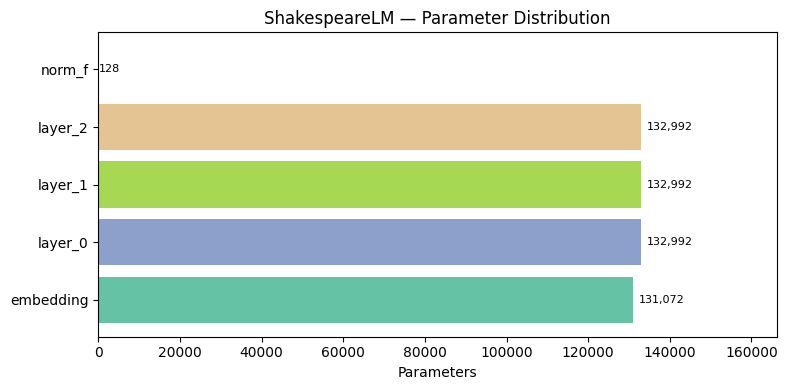

In [ ]:
# ── Parameter breakdown ───────────────────────────────────────────────────
groups = {}
groups["embedding"] = model.embedding.weight.numel()
for i, layer in enumerate(model.layers):
    mb = layer.mamba_block
    layer_total = sum(p.numel() for p in layer.parameters())
    groups[f"layer_{i}"] = layer_total
groups["norm_f"] = sum(p.numel() for p in model.norm_f.parameters())
# lm_head is tied to embedding — show it but note it
groups["lm_head (tied)"] = 0

print(f"{'Component':<22} {'Params':>10}  {'Share':>6}")
print("-" * 42)
total_show = sum(groups.values())
for k, n in groups.items():
    pct = 100 * n / total_show if total_show > 0 else 0
    print(f"{k:<22} {n:>10,}  {pct:>5.1f}%")
print("-" * 42)
print(f"{'Unique total':<22} {n_params_unique:>10,}")

fig, ax = plt.subplots(figsize=(8, 4))
plot_groups = {k: v for k, v in groups.items() if v > 0}
names = list(plot_groups.keys())
vals  = list(plot_groups.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))
bars = ax.barh(names, vals, color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}", va="center", fontsize=8)
ax.set_xlabel("Parameters")
ax.set_title("ShakespeareLM — Parameter Distribution")
ax.set_xlim(0, max(vals) * 1.25)
plt.tight_layout()
plt.show()


## 3. Data Pipeline & Profiling

- **Data pipeline**: PyTorch `Dataset` + `DataLoader` with `pin_memory`,
  `num_workers`, and `persistent_workers` for async prefetching
- **Profiler**: `torch.profiler` on one forward + backward step to
  understand where time and memory are spent before committing to full training


In [ ]:
# ── Dataset & DataLoader ──────────────────────────────────────────────────
class ShakespeareDataset(Dataset):
    def __init__(self, data, seq_len, stride=None):
        self.data    = data
        self.seq_len = seq_len
        self.stride  = stride or seq_len // 2   # 50% overlap by default

    def __len__(self):
        return max(0, (len(self.data) - self.seq_len) // self.stride)

    def __getitem__(self, idx):
        start = idx * self.stride
        x = self.data[start     : start + self.seq_len]
        y = self.data[start + 1 : start + self.seq_len + 1]
        return x, y

train_dataset = ShakespeareDataset(train_data, cfg.seq_len, cfg.stride)
val_dataset   = ShakespeareDataset(val_data,   cfg.seq_len)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
)

tokens_per_batch = cfg.batch_size * cfg.seq_len
print(f"Train dataset:  {len(train_dataset):>10,} samples")
print(f"Val dataset:    {len(val_dataset):>10,} samples")
print(f"Train batches / epoch: {len(train_loader):>5}")
print(f"Val   batches / epoch: {len(val_loader):>5}")
print(f"Tokens per batch:      {tokens_per_batch:>5,}  "
      f"({cfg.batch_size} x {cfg.seq_len})")

# Sanity check
xb, yb = next(iter(train_loader))
print(f"\nBatch shapes: x={tuple(xb.shape)}  y={tuple(yb.shape)}")
print(f"Sample input  (first 40 tokens): '{decode(xb[0, :40].tolist())}'")
print(f"Sample target (first 40 tokens): '{decode(yb[0, :40].tolist())}'")


Train dataset:       1,541 samples
Val dataset:            83 samples
Train batches / epoch:    24
Val   batches / epoch:     1
Tokens per batch:      65,536  (64 x 1024)

Batch shapes: x=(64, 1024)  y=(64, 1024)
Sample input  (first 40 tokens): 'usiness!'

SICINIUS:
Besides, if things go well,
Opinion that so sticks on Marcius shall
Of his dem'
Sample target (first 40 tokens): 'iness!'

SICINIUS:
Besides, if things go well,
Opinion that so sticks on Marcius shall
Of his demer'


Top-20 operations by CUDA time
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                forward         0.00%       0.000us         0.00%       0.000us       0.000us     512.068ms        55.53%     512.068ms     512.068ms           0 B          

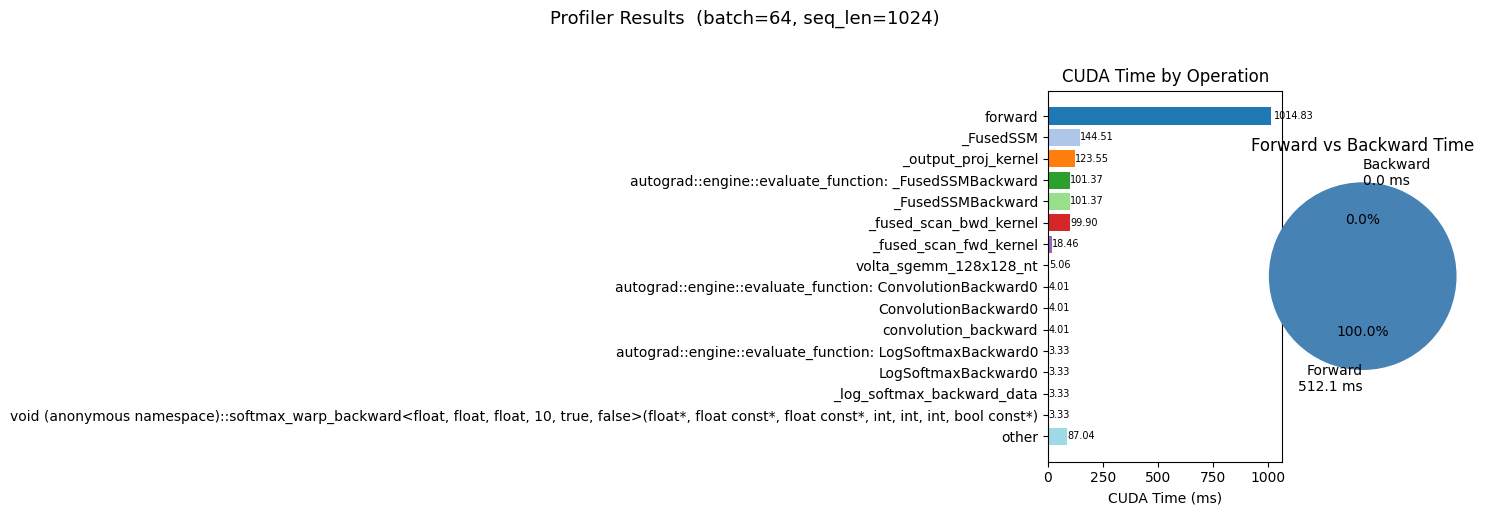


────────────────────────────────────────────────────────────
Peak CUDA memory allocated: 10221.3 MB
Peak CUDA memory reserved:  13436.0 MB
Current CUDA memory allocated: 323.9 MB
────────────────────────────────────────────────────────────

Trace exported to mamba_profile_trace.json
Open https://ui.perfetto.dev and drag the file in to visualize.


ShakespeareLM(
  (embedding): Embedding(1024, 128)
  (layers): ModuleList(
    (0-2): 3 x ResidualBlock(
      (mamba_block): MambaBlock(
        (input_proj): Linear(in_features=128, out_features=256, bias=False)
        (res_proj): Linear(in_features=128, out_features=256, bias=False)
        (output_proj): Linear(in_features=256, out_features=128, bias=False)
        (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
        (x_B_proj): Linear(in_features=256, out_features=32, bias=False)
        (x_C_proj): Linear(in_features=256, out_features=32, bias=False)
        (x_dt_proj): Linear(in_features=256, out_features=16, bias=False)
        (dt_proj): Linear(in_features=16, out_features=256, bias=True)
      )
      (norm): RMSNorm()
    )
  )
  (norm_f): RMSNorm()
  (lm_head): Linear(in_features=128, out_features=1024, bias=False)
)

In [ ]:
# ── Torch Profiler: understand where time is spent ───────────────────────
from torch.profiler import profile, ProfilerActivity, record_function

model.eval()

# Warm up the GPU (discard first few runs)
with torch.no_grad():
    for _ in range(3):
        xb, yb = next(iter(val_loader))
        xb, yb = xb.to(device), yb.to(device)
        model(xb, yb)
torch.cuda.synchronize()

# ── Profile a forward + backward pass ─────────────────────────────────────
model.train()
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=False,
) as prof:
    with record_function("forward"):
        logits, loss = model(xb, yb)
    with record_function("backward"):
        loss.backward()

torch.cuda.synchronize()

# ── Top-20 operations by CUDA time ───────────────────────────────────────
print("Top-20 operations by CUDA time")
print("=" * 100)
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=20))

# ── Top-20 by CPU time ──────────────────────────────────────────────────
print("\nTop-20 operations by CPU time")
print("=" * 100)
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=20))

# ── Memory summary ───────────────────────────────────────────────────────
print("\nTop-15 operations by CUDA memory allocated")
print("=" * 100)
print(prof.key_averages().table(sort_by="cuda_memory_usage", row_limit=15))

# ── Visualize: CUDA time breakdown by op category ────────────────────────
averages = prof.key_averages()

# Group by operation category
op_times = {}
for evt in averages:
    if evt.device_time > 0:
        key = evt.key
        if "aten::" in key:
            cat = key.split("aten::")[-1]
        elif key in ("forward", "backward"):
            cat = key
        else:
            cat = key
        op_times[cat] = op_times.get(cat, 0) + evt.device_time

sorted_ops = sorted(op_times.items(), key=lambda x: x[1], reverse=True)
top_n = 15
top_ops = sorted_ops[:top_n]
other_time = sum(t for _, t in sorted_ops[top_n:])
if other_time > 0:
    top_ops.append(("other", other_time))

op_names = [name for name, _ in top_ops]
op_vals  = [t / 1000 for _, t in top_ops]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = plt.cm.tab20(np.linspace(0, 1, len(op_names)))
bars = axes[0].barh(op_names[::-1], op_vals[::-1], color=colors[::-1])
axes[0].set_xlabel("CUDA Time (ms)")
axes[0].set_title("CUDA Time by Operation")
for bar, v in zip(bars, op_vals[::-1]):
    axes[0].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                 f"{v:.2f}", va="center", fontsize=7)

fwd_time = 0
bwd_time = 0
for evt in averages:
    if evt.key == "forward":
        fwd_time = evt.device_time / 1000
    elif evt.key == "backward":
        bwd_time = evt.device_time / 1000
if fwd_time > 0 or bwd_time > 0:
    axes[1].pie(
        [fwd_time, bwd_time],
        labels=[f"Forward\n{fwd_time:.1f} ms", f"Backward\n{bwd_time:.1f} ms"],
        colors=["steelblue", "darkorange"],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 10},
    )
    axes[1].set_title("Forward vs Backward Time")
else:
    total_cuda = sum(op_vals)
    axes[1].text(0.5, 0.5, f"Total CUDA time: {total_cuda:.1f} ms",
                 ha="center", va="center", fontsize=14,
                 transform=axes[1].transAxes)
    axes[1].set_title("Total CUDA Time")

plt.suptitle(f"Profiler Results  (batch={cfg.batch_size}, seq_len={cfg.seq_len})",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

if torch.cuda.is_available():
    print(f"\n{'─' * 60}")
    print(f"Peak CUDA memory allocated: "
          f"{torch.cuda.max_memory_allocated() / 1024**2:.1f} MB")
    print(f"Peak CUDA memory reserved:  "
          f"{torch.cuda.max_memory_reserved() / 1024**2:.1f} MB")
    print(f"Current CUDA memory allocated: "
          f"{torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"{'─' * 60}")

TRACE_PATH = "mamba_profile_trace.json"
prof.export_chrome_trace(TRACE_PATH)
print(f"\nTrace exported to {TRACE_PATH}")
print("Open https://ui.perfetto.dev and drag the file in to visualize.")

model.zero_grad(set_to_none=True)
model.eval()


## 4. Training

- **Optimizer**: AdamW with cosine LR schedule
- **Loss**: cross-entropy (next token prediction)


In [ ]:
torch.cuda.empty_cache()


In [ ]:
wandb.init(
    project='mamba-stories',
    config=vars(cfg),
)

# ── Training loop ─────────────────────────────────────────────────────────
steps_per_epoch = len(train_loader)
total_steps     = cfg.epochs * steps_per_epoch
tokens_per_step = cfg.batch_size * cfg.seq_len

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=0.3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=total_steps, eta_min=cfg.lr / 10
)

train_losses = []
val_losses   = []
lr_history   = []
step_times   = []

@torch.no_grad()
def estimate_val_loss(n_batches=20):
    model.eval()
    losses = []
    for i, (xb, yb) in enumerate(val_loader):
        if i >= n_batches:
            break
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return np.mean(losses)

print(f"Training for {cfg.epochs} epoch(s)  |  {steps_per_epoch:,} steps/epoch  "
      f"|  {total_steps:,} total steps")
print(f"seq_len={cfg.seq_len}  batch={cfg.batch_size}  "
      f"({tokens_per_step:,} tok/step  {total_steps * tokens_per_step:,} tok total)")
print(f"{'─' * 70}")

model.train()
best_val    = float("inf")
global_step = 0

for epoch in range(cfg.epochs):
    epoch_loss = 0.0
    with tqdm(train_loader, unit="batch") as tepoch:
        for batch_idx, (xb, yb) in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")
            t0 = time.time()

            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            logits, loss = model(xb, yb)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            dt = time.time() - t0
            loss_val = loss.item()
            train_losses.append(loss_val)
            lr = scheduler.get_last_lr()[0]
            lr_history.append(lr)
            step_times.append(dt)
            epoch_loss += loss_val
            global_step += 1
            tepoch.set_postfix(loss=loss_val)
            wandb.log({"Training Loss": loss_val,
                       "Batch Time": dt,
                       "Learning Rate": lr})

            if global_step == 1 or global_step % cfg.eval_every_n_batches == 0:
                val_loss = estimate_val_loss()
                val_losses.append((global_step, val_loss))
                if val_loss < best_val:
                    best_val = val_loss
                ppl = math.exp(val_loss)
                tps = tokens_per_step / np.mean(step_times[-50:])
                print(f"Epoch {epoch+1}/{cfg.epochs}  "
                      f"step {global_step:>6d}/{total_steps}  |  "
                      f"train {loss.item():.4f}  val {val_loss:.4f}  "
                      f"ppl {ppl:.1f}  lr {lr:.1e}  "
                      f"{tps/1000:.1f}k tok/s")
                wandb.log({"Validation Loss": val_loss,
                           "Validation PPL": ppl})

    # End-of-epoch eval
    val_loss = estimate_val_loss()
    ppl = math.exp(val_loss)
    val_losses.append((global_step, val_loss))
    if val_loss < best_val:
        best_val = val_loss
    avg_epoch_loss = epoch_loss / steps_per_epoch
    print(f"{'─' * 70}")
    print(f"Epoch {epoch+1} done  |  avg train {avg_epoch_loss:.4f}  "
          f"val {val_loss:.4f}  ppl {ppl:.1f}")
    print(f"{'─' * 70}")
    wandb.log({"Validation Loss": val_loss, "Validation PPL": ppl})

total_tokens = global_step * tokens_per_step
print(f"\nTraining complete.  {total_tokens:,} tokens processed over "
      f"{cfg.epochs} epoch(s).")
print(f"Best val loss: {best_val:.4f}  (ppl {math.exp(best_val):.1f})")

## 5. Evaluation & Metrics


In [ ]:
# Recreate val_loader without workers (in case persistent workers died)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=True,
)


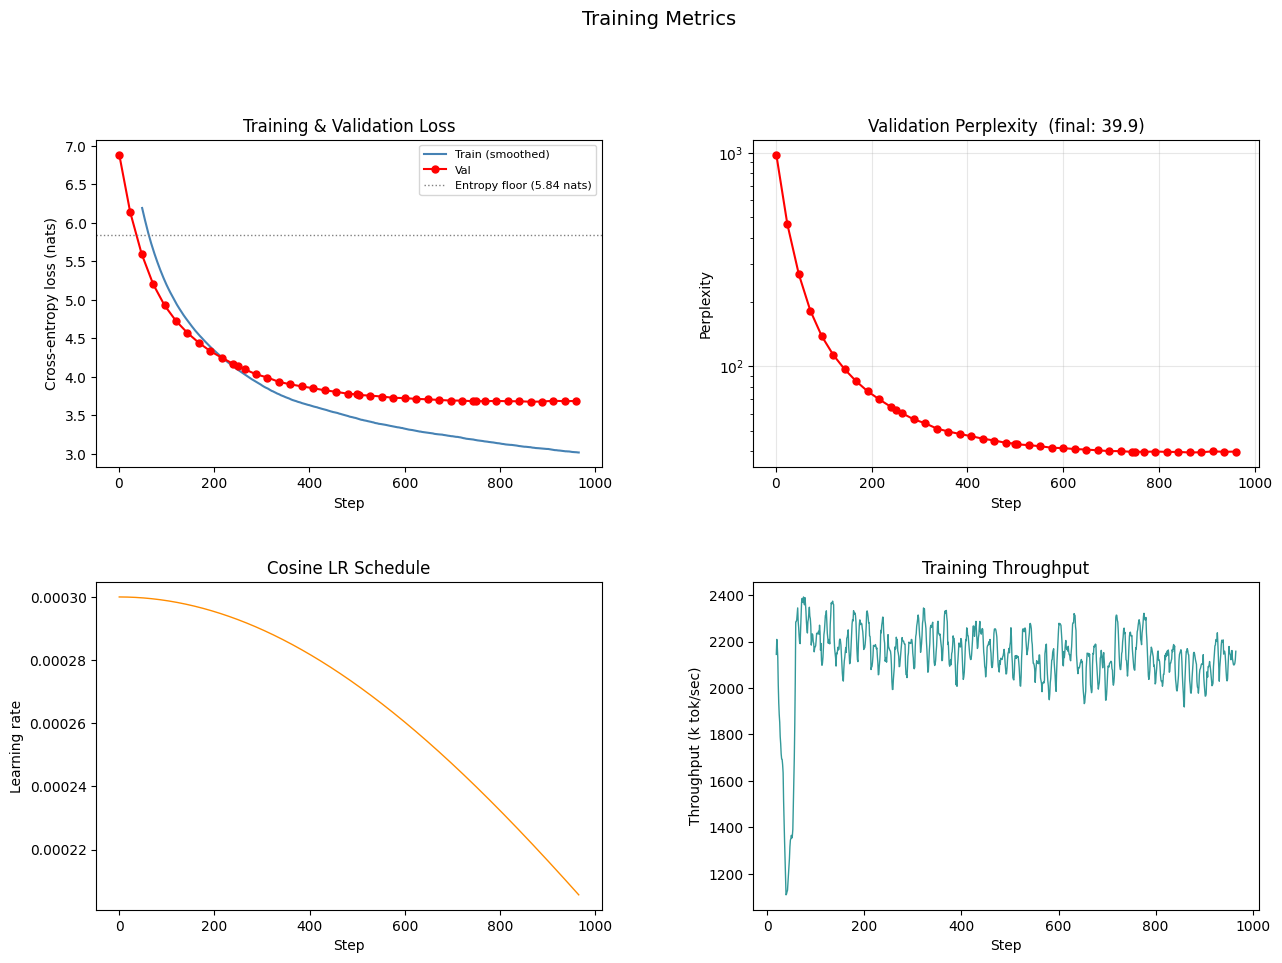

Tokenizer:                     bpe (vocab=1024)
Final val loss (nats):         3.6858
Final val perplexity:          39.9
Best val loss:                 3.6763
Best val perplexity:           39.5
Token entropy (nats):          5.8433
Total training time:           29.9s
Unique parameters:             399,104


In [ ]:
# ── Loss & perplexity curves ─────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# (a) Loss curve
ax1 = fig.add_subplot(gs[0, 0])
W = 50
smooth = np.convolve(train_losses, np.ones(W) / W, mode="valid")
ax1.plot(range(W - 1, len(train_losses)), smooth,
         color="steelblue", linewidth=1.5, label="Train (smoothed)")
vx, vy = zip(*val_losses)
ax1.plot(vx, vy, "ro-", markersize=5, linewidth=1.5, label="Val")
ax1.axhline(H * math.log(2), color="gray", linestyle=":", linewidth=1,
            label=f"Entropy floor ({H * math.log(2):.2f} nats)")
ax1.set_xlabel("Step")
ax1.set_ylabel("Cross-entropy loss (nats)")
ax1.set_title("Training & Validation Loss")
ax1.legend(fontsize=8)

# (b) Perplexity
ax2 = fig.add_subplot(gs[0, 1])
val_ppl = [(s, math.exp(l)) for s, l in val_losses]
vx_p, vy_p = zip(*val_ppl)
ax2.plot(vx_p, vy_p, "ro-", markersize=5, linewidth=1.5)
ax2.set_xlabel("Step")
ax2.set_ylabel("Perplexity")
ax2.set_title(f"Validation Perplexity  (final: {vy_p[-1]:.1f})")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

# (c) Learning rate schedule
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(lr_history, color="darkorange", linewidth=1)
ax3.set_xlabel("Step")
ax3.set_ylabel("Learning rate")
ax3.set_title("Cosine LR Schedule")

# (d) Throughput
ax4 = fig.add_subplot(gs[1, 1])
W2 = 20
smooth_times = np.convolve(step_times, np.ones(W2) / W2, mode="valid")
tokens_per_step_metric = cfg.batch_size * cfg.seq_len
throughput = tokens_per_step_metric / smooth_times
ax4.plot(range(W2 - 1, len(step_times)), throughput / 1000,
         color="teal", linewidth=1, alpha=0.8)
ax4.set_xlabel("Step")
ax4.set_ylabel("Throughput (k tok/sec)")
ax4.set_title("Training Throughput")

plt.suptitle("Training Metrics", fontsize=14, y=1.01)
plt.show()

final_val = val_losses[-1][1]
final_ppl = math.exp(final_val)
total_time = sum(step_times)
print(f"{'=' * 50}")
print(f"{'Tokenizer:':<30} {TOKENIZER_MODE} (vocab={vocab_size})")
print(f"{'Final val loss (nats):':<30} {final_val:.4f}")
print(f"{'Final val perplexity:':<30} {final_ppl:.1f}")
print(f"{'Best val loss:':<30} {best_val:.4f}")
print(f"{'Best val perplexity:':<30} {math.exp(best_val):.1f}")
print(f"{'Token entropy (nats):':<30} {H * math.log(2):.4f}")
print(f"{'Total training time:':<30} {total_time:.1f}s")
print(f"{'Unique parameters:':<30} {n_params_unique:,}")
print(f"{'=' * 50}")


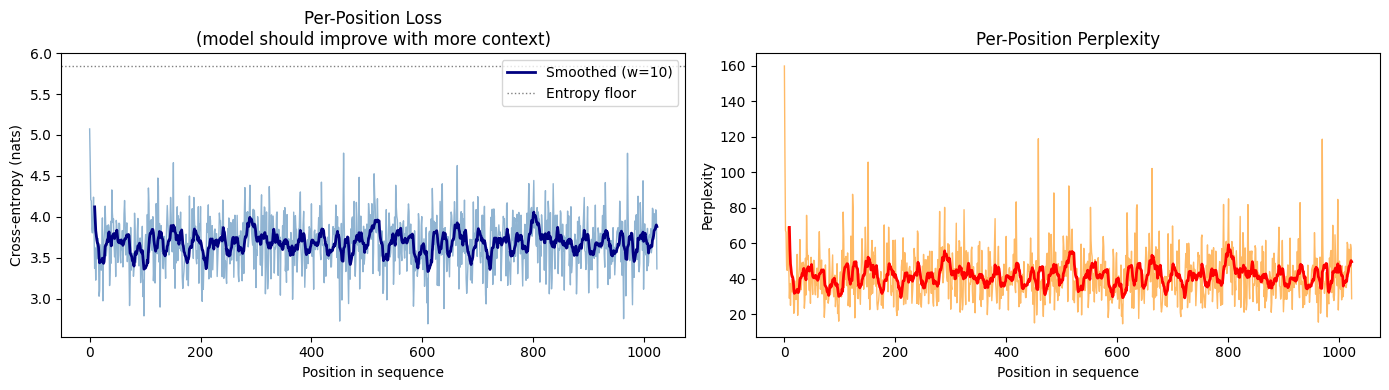

Position  1 loss: 5.074  ppl: 159.8
Position 10 loss: 3.370  ppl: 29.1
Position 1024 loss: 3.363  ppl: 28.9

The model sees more context at later positions -> lower loss


In [ ]:
# ── Per-position loss (does the model improve with more context?) ────────
model.eval()

n_eval_batches = 30
pos_losses = torch.zeros(cfg.seq_len, device=device)
pos_counts = torch.zeros(cfg.seq_len, device=device)

with torch.no_grad():
    for i, (xb, yb) in enumerate(val_loader):
        if i >= n_eval_batches:
            break
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits, _ = model(xb, yb)
        log_probs = F.log_softmax(logits, dim=-1)
        target_log_probs = log_probs.gather(2, yb.unsqueeze(-1)).squeeze(-1)
        nll = -target_log_probs
        pos_losses += nll.sum(dim=0)
        pos_counts += xb.shape[0]

avg_pos_loss = (pos_losses / pos_counts).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(avg_pos_loss, color="steelblue", linewidth=1, alpha=0.6)
W3 = 10
smooth_pos = np.convolve(avg_pos_loss, np.ones(W3) / W3, mode="valid")
axes[0].plot(range(W3 - 1, len(avg_pos_loss)), smooth_pos,
             color="navy", linewidth=2, label=f"Smoothed (w={W3})")
axes[0].axhline(H * math.log(2), color="gray", linestyle=":", linewidth=1,
                label="Entropy floor")
axes[0].set_xlabel("Position in sequence")
axes[0].set_ylabel("Cross-entropy (nats)")
axes[0].set_title("Per-Position Loss\n(model should improve with more context)")
axes[0].legend()

pos_ppl = np.exp(avg_pos_loss)
axes[1].plot(pos_ppl, color="darkorange", linewidth=1, alpha=0.6)
smooth_ppl = np.convolve(pos_ppl, np.ones(W3) / W3, mode="valid")
axes[1].plot(range(W3 - 1, len(pos_ppl)), smooth_ppl,
             color="red", linewidth=2)
axes[1].set_xlabel("Position in sequence")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Per-Position Perplexity")

plt.tight_layout()
plt.show()

print(f"Position  1 loss: {avg_pos_loss[0]:.3f}  ppl: {math.exp(avg_pos_loss[0]):.1f}")
print(f"Position 10 loss: {avg_pos_loss[9]:.3f}  ppl: {math.exp(avg_pos_loss[9]):.1f}")
print(f"Position {cfg.seq_len} loss: {avg_pos_loss[-1]:.3f}  "
      f"ppl: {math.exp(avg_pos_loss[-1]):.1f}")
print(f"\nThe model sees more context at later positions -> lower loss")


In [ ]:
# ── Next-token prediction confidence ──────────────────────────────────────
model.eval()

# Use a story-appropriate test passage
test_text = "Once upon a time there was a little girl named Lily. She loved to play in the garden."
test_ids = torch.tensor(encode(test_text), dtype=torch.long, device=device).unsqueeze(0)

with torch.no_grad():
    logits, _ = model(test_ids)
    probs = F.softmax(logits[0], dim=-1)

L_show = min(50, test_ids.shape[1] - 1)
print(f"{'Pos':>4}  {'Actual':>10}  {'P(actual)':>9}  "
      f"{'Top-1':>10} {'P(top1)':>8}  {'Top-2':>10} {'Top-3':>10}")
print("-" * 80)

correct = 0
for t in range(L_show):
    actual_id = test_ids[0, t + 1].item()
    p = probs[t]
    p_actual = p[actual_id].item()
    top3 = p.topk(3)
    top_strs = [repr(decode([i.item()]))[1:-1] for i in top3.indices]
    top_probs = top3.values.tolist()
    actual_str = repr(decode([actual_id]))[1:-1]
    hit = "*" if top3.indices[0].item() == actual_id else " "
    if top3.indices[0].item() == actual_id:
        correct += 1
    print(f"{t:>4}  {actual_str:>10}  {p_actual:>9.4f}  "
          f"{top_strs[0]:>10} {top_probs[0]:>7.4f}  "
          f"{top_strs[1]:>10} {top_strs[2]:>10}  {hit}")

print(f"\nTop-1 accuracy: {correct}/{L_show} = {correct/L_show:.1%}")

fig, ax = plt.subplots(figsize=(14, 5))
prob_np = probs[:L_show].cpu().numpy()
flat_sum = prob_np.sum(axis=0)
top_chars_idx = np.argsort(flat_sum)[-15:][::-1]
heatmap = prob_np[:, top_chars_idx].T
char_labels = [repr(decode([i]))[1:-1] for i in top_chars_idx]
im = ax.imshow(heatmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

for t in range(L_show):
    actual = test_ids[0, t + 1].item()
    if actual in top_chars_idx:
        row = list(top_chars_idx).index(actual)
        ax.plot(t, row, "ks", markersize=4)

ax.set_yticks(range(len(char_labels)))
ax.set_yticklabels(char_labels, fontfamily="monospace")
ax.set_xlabel("Position in sequence")
ax.set_title("Prediction Probabilities  (black squares = actual next token)")
plt.colorbar(im, ax=ax, label="P(token)")
plt.tight_layout()
plt.show()

## 6. Text Generation

Let's sample from the trained model with different temperatures and prompts.


In [ ]:
# ── Generation function ───────────────────────────────────────────────────
def generate_text(prompt, max_tokens=300, temperature=0.8, top_k=40):
    model.eval()
    ids = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    out = model.generate(ids, max_new_tokens=max_tokens,
                         temperature=temperature, top_k=top_k)
    return decode(out[0].tolist())

# ── Sample with different temperatures ────────────────────────────────────
prompts = [
    "Once upon a time",
    "The little boy was very happy because",
    "One sunny day, a girl named",
    "There was a big red",
]

temp_text_table = wandb.Table(columns=["Temp", "text"])

for temp in [0.5, 0.8, 1.0]:
    print(f"\n{'=' * 60}")
    print(f"Temperature = {temp}")
    print(f"{'=' * 60}")
    prompt = random.choice(prompts)
    output = generate_text(prompt, max_tokens=250, temperature=temp, top_k=40)
    print(output)
    temp_text_table.add_data(temp, output)
wandb.log({"Temperature Output": temp_text_table})

In [ ]:
# ── Temperature comparison: entropy of generated text ─────────────────────
temperatures = [0.3, 0.5, 0.7, 0.8, 1.0, 1.2]
gen_entropies = []
gen_samples   = []

for temp in temperatures:
    model.eval()
    ids = torch.tensor(encode("Once upon a time"), dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        out = model.generate(ids, max_new_tokens=500, temperature=temp, top_k=50)
    gen_text = decode(out[0].tolist())
    gen_samples.append(gen_text[:200])

    gen_ids = torch.tensor(encode(gen_text), dtype=torch.long)
    gen_counts = torch.bincount(gen_ids, minlength=vocab_size).float()
    gen_freq   = gen_counts / gen_counts.sum()
    gen_H = -(gen_freq[gen_freq > 0] * gen_freq[gen_freq > 0].log2()).sum().item()
    gen_entropies.append(gen_H)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(temperatures, gen_entropies, "o-", color="steelblue",
             linewidth=2, markersize=8)
axes[0].axhline(H, color="red", linestyle="--", label=f"Corpus H={H:.2f}")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Entropy (bits/token)")
axes[0].set_title("Generated Text Entropy vs Temperature")
axes[0].legend()

idx_08 = temperatures.index(0.8)
gen_08 = gen_samples[idx_08]
gen_counts_08 = torch.bincount(
    torch.tensor(encode(gen_08), dtype=torch.long), minlength=vocab_size
).float()
gen_freq_08 = gen_counts_08 / gen_counts_08.sum()

top_20 = freqs.argsort(descending=True)[:20]
x_pos = np.arange(20)
w = 0.35
axes[1].bar(x_pos - w/2, freqs[top_20].numpy(), w,
            label="SimpleStories", color="steelblue", alpha=0.8)
axes[1].bar(x_pos + w/2, gen_freq_08[top_20].numpy(), w,
            label="Generated (T=0.8)", color="darkorange", alpha=0.8)
axes[1].set_xticks(x_pos)
if TOKENIZER_MODE == "char":
    xlabels = [repr(decode([i.item()]))[1:-1] for i in top_20]
else:
    xlabels = [repr(decode([i.item()]))[1:-1][:8] for i in top_20]
axes[1].set_xticklabels(xlabels, fontfamily="monospace", fontsize=7, rotation=45)
axes[1].set_ylabel("Frequency")
axes[1].set_title("Token Distribution: Corpus vs Generated")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ── Final showcase generation ─────────────────────────────────────────────
print("=" * 60)
print("FINAL GENERATION SHOWCASE")
print("=" * 60)

showcase_prompts = [
    "Once upon a time there was a little cat who loved to explore.",
    "The boy found a shiny key on the ground. He picked it up and",
    "One day, a friendly dragon came to the village. The children were",
]

final_text_table = wandb.Table(columns=["Prompt", "text"])

for prompt in showcase_prompts:
    print(f"\n{'─' * 60}")
    print(f"PROMPT: {prompt[:60]}...")
    print(f"{'─' * 60}")
    output = generate_text(prompt, max_tokens=300, temperature=0.8, top_k=40)
    print(output)
    final_text_table.add_data(prompt.strip(), output)

wandb.log({"Final Generation": final_text_table})
print(f"\n{'═' * 60}")
print(f"Model: {cfg.n_layer}-layer Mamba LM, {n_params_unique:,} params")
print(f"Tokenizer: {TOKENIZER_MODE} (vocab={vocab_size})")
print(f"Trained on {len(train_data):,} tokens ({ds['train'].num_rows:,} stories) "
      f"for {cfg.epochs} epoch(s)")
print(f"Final perplexity: {math.exp(best_val):.1f}")
print(f"{'═' * 60}")

wandb.finish()